**A. Persiapan Lingkungan dan Pemuatan Data**

In [9]:
# A. IMPOR PUSTAKA YANG DIBUTUHKAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc

# B. MUAT DATASET
print("Langkah 1: Pemuatan Data...")
# Muat dataset dan konversi ke Pandas DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame

print("Data berhasil dimuat.")
print(f"Total Sampel: {len(df)}")
print("\n5 Baris Pertama Dataset:")
print(df.head())

Langkah 1: Pemuatan Data...
Data berhasil dimuat.
Total Sampel: 569

5 Baris Pertama Dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

**B. Pra-pemrosesan dan Pelatihan Model**

In [10]:
# C. PISAHKAN FITUR (X) DAN TARGET (y)
X = df.drop(columns=['target']) # Fitur (Input)
y = df['target']              # Target (Output: 0=Benign, 1=Malignant)

# D. BAGI DATA MENJADI SET PELATIHAN DAN PENGUJIAN (80:20)
print("\nLangkah 2: Pra-pemrosesan Data (Splitting)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# E. INISIALISASI DAN PELATIHAN MODEL
print("Langkah 3: Pelatihan Model Gaussian Naive Bayes...")
model_nb = GaussianNB()

# Melatih model
model_nb.fit(X_train, y_train)

# Prediksi pada data pengujian
y_pred = model_nb.predict(X_test)

print("Model berhasil dilatih dan prediksi telah dibuat.")


Langkah 2: Pra-pemrosesan Data (Splitting)...
Langkah 3: Pelatihan Model Gaussian Naive Bayes...
Model berhasil dilatih dan prediksi telah dibuat.


**C. Evaluasi dan Visualisasi Hasil**

1.Metrik Evaluasi


In [11]:
print("\n=== EVALUASI HASIL PREDIKSI ===")

# Akurasi Keseluruhan
accuracy = accuracy_score(y_test, y_pred)
print(f"1. AKURASI MODEL: {accuracy:.4f}")

# Classification Report
print("\n2. CLASSIFICATION REPORT (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred, target_names=['Jinak (Benign)', 'Ganas (Malignant)']))


=== EVALUASI HASIL PREDIKSI ===
1. AKURASI MODEL: 0.9737

2. CLASSIFICATION REPORT (Precision, Recall, F1-Score):
                   precision    recall  f1-score   support

   Jinak (Benign)       1.00      0.93      0.96        43
Ganas (Malignant)       0.96      1.00      0.98        71

         accuracy                           0.97       114
        macro avg       0.98      0.97      0.97       114
     weighted avg       0.97      0.97      0.97       114



2. Visualisasi Confusion Matrix


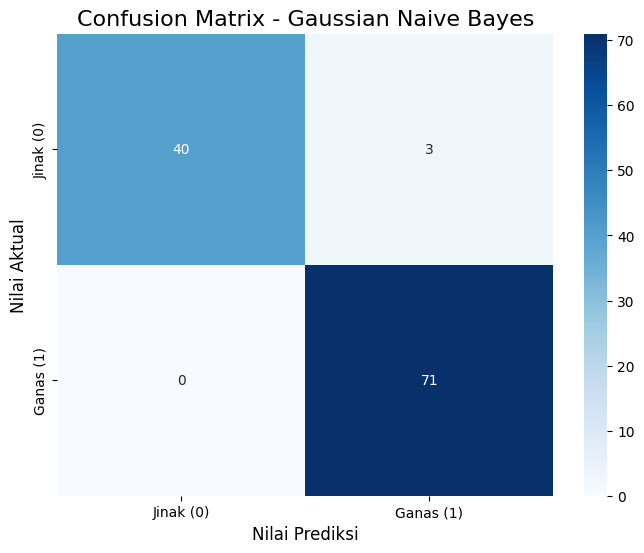

In [12]:
# Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
class_names = ['Jinak (0)', 'Ganas (1)']

# Visualisasi Heatmap Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - Gaussian Naive Bayes', fontsize=16)
plt.ylabel('Nilai Aktual', fontsize=12)
plt.xlabel('Nilai Prediksi', fontsize=12)
plt.show()

3. Visualisasi ROC Curve dan AUC

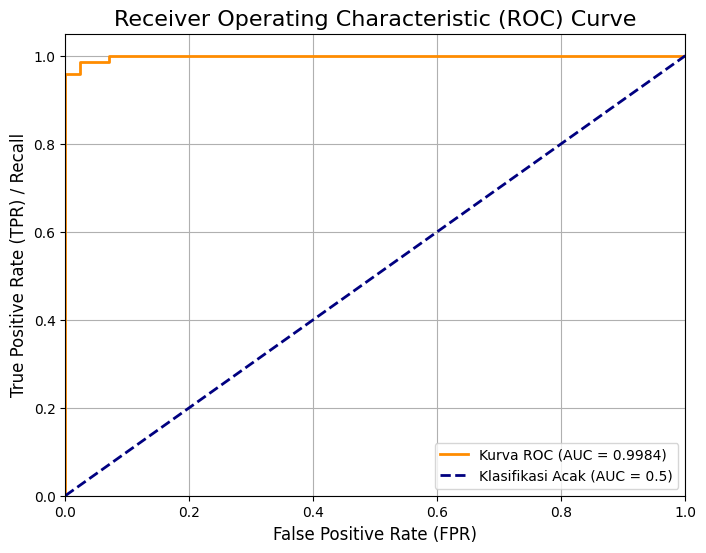

In [13]:
# Hitung probabilitas prediksi
y_proba = model_nb.predict_proba(X_test)[:, 1]

# Hitung FPR, TPR, dan Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Hitung Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# PLOT ROC CURVE
plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'Kurva ROC (AUC = {roc_auc:.4f})'
)

# Garis referensi (Klasifikasi Acak)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Klasifikasi Acak (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()